In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D

sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
from funcs import *
from processing_funcs import *
from theoretical import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_260126/')

#figpath = '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm/Figures/'

%load_ext autoreload
%autoreload 2

Reading in the pre-processed files

The files are cleaned, detrended, corrected for outliers and later combined as the mean of three consecutive runs per experiment.

In [13]:
# f = 1.1 Hz
# Empty tank
f1_a1 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f11_a01_processed.csv')
f1_a2 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f11_a02_processed.csv')
f1_a3 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f11_a03_processed.csv')

# With 5 cm tall plates
f1_a1_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f11_a01_p005_processed.csv')
f1_a2_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f11_a02_p005_processed.csv')
f1_a3_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f11_a03_p005_processed.csv')

# With 10 cm tall plates

# f = 1.2 Hz
# Empty tank
f2_a1 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f12_a01_processed.csv')
f2_a2 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f12_a02_processed.csv')
f2_a3 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f12_a03_processed.csv')

# With 5 cm tall plates
f2_a1_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f12_a01_p005_processed.csv')
f2_a2_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f12_a02_p005_processed.csv')
f2_a3_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f12_a03_p005_processed.csv')

# With 10 cm tall plates

# f = 1.3 Hz
# Empty tank
f3_a1 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f13_a01_processed.csv')
f3_a2 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f13_a02_processed.csv')
f3_a3 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f13_a03_processed.csv')

# With 5 cm tall plates
f3_a1_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f13_a01_p005_processed.csv')
f3_a2_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f13_a02_p005_processed.csv')
f3_a3_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f13_a03_p005_processed.csv')

# With 10 cm tall plates

In [3]:
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])  # Base positions, meters from wave maker

plate_pos = np.array([6.34, 9.38])  # Positions of the plates, meters from wave maker

In [4]:
std_f1_a1 = [f1_a1['P_0'].std(), f1_a1['P_1'].std(), f1_a1['P_2'].std(), f1_a1['P_3'].std()]
std_f1_a1_p005 = [f1_a1_p005['P_0'].std(), f1_a1_p005['P_1'].std(), f1_a1_p005['P_2'].std(), f1_a1_p005['P_3'].std()]

std_f1_a2 = [f1_a2['P_0'].std(), f1_a2['P_1'].std(), f1_a2['P_2'].std(), f1_a2['P_3'].std()]
std_f1_a2_p005 = [f1_a2_p005['P_0'].std(), f1_a2_p005['P_1'].std(), f1_a2_p005['P_2'].std(), f1_a2_p005['P_3'].std()]

std_f1_a3 = [f1_a3['P_0'].std(), f1_a3['P_1'].std(), f1_a3['P_2'].std(), f1_a3['P_3'].std()]
std_f1_a3_p005 = [f1_a3_p005['P_0'].std(), f1_a3_p005['P_1'].std(), f1_a3_p005['P_2'].std(), f1_a3_p005['P_3'].std()]

amp_f1_a1 = np.sqrt(2) * np.array(std_f1_a1)
amp_f1_a1_p005 = np.sqrt(2) * np.array(std_f1_a1_p005)
amp_f1_a2 = np.sqrt(2) * np.array(std_f1_a2)
amp_f1_a2_p005 = np.sqrt(2) * np.array(std_f1_a2_p005)
amp_f1_a3 = np.sqrt(2) * np.array(std_f1_a3)
amp_f1_a3_p005 = np.sqrt(2) * np.array(std_f1_a3_p005)

std_err_f1_a1 = np.array(std_f1_a1) / np.sqrt(len(f1_a1))
std_err_f1_a1_p005 = np.array(std_f1_a1_p005) / np.sqrt(len(f1_a1_p005))
std_err_f1_a2 = np.array(std_f1_a2) / np.sqrt(len(f1_a2))
std_err_f1_a2_p005 = np.array(std_f1_a2_p005) / np.sqrt(len(f1_a2_p005))
std_err_f1_a3 = np.array(std_f1_a3) / np.sqrt(len(f1_a3))
std_err_f1_a3_p005 = np.array(std_f1_a3_p005) / np.sqrt(len(f1_a3_p005))

In [5]:
std_f2_a1 = [f2_a1['P_0'].std(), f2_a1['P_1'].std(), f2_a1['P_2'].std(), f2_a1['P_3'].std()]
std_f2_a1_p005 = [f2_a1_p005['P_0'].std(), f2_a1_p005['P_1'].std(), f2_a1_p005['P_2'].std(), f2_a1_p005['P_3'].std()]

std_f2_a2 = [f2_a2['P_0'].std(), f2_a2['P_1'].std(), f2_a2['P_2'].std(), f2_a2['P_3'].std()]
std_f2_a2_p005 = [f2_a2_p005['P_0'].std(), f2_a2_p005['P_1'].std(), f2_a2_p005['P_2'].std(), f2_a2_p005['P_3'].std()]

std_f2_a3 = [f2_a3['P_0'].std(), f2_a3['P_1'].std(), f2_a3['P_2'].std(), f2_a3['P_3'].std()]
std_f2_a3_p005 = [f2_a3_p005['P_0'].std(), f2_a3_p005['P_1'].std(), f2_a3_p005['P_2'].std(), f2_a3_p005['P_3'].std()]

amp_f2_a1 = np.sqrt(2) * np.array(std_f2_a1)
amp_f2_a1_p005 = np.sqrt(2) * np.array(std_f2_a1_p005)
amp_f2_a2 = np.sqrt(2) * np.array(std_f2_a2)
amp_f2_a2_p005 = np.sqrt(2) * np.array(std_f2_a2_p005)
amp_f2_a3 = np.sqrt(2) * np.array(std_f2_a3)
amp_f2_a3_p005 = np.sqrt(2) * np.array(std_f2_a3_p005)

std_err_f2_a1 = np.array(std_f2_a1) / np.sqrt(len(f2_a1))
std_err_f2_a1_p005 = np.array(std_f2_a1_p005) / np.sqrt(len(f2_a1_p005))
std_err_f2_a2 = np.array(std_f2_a2) / np.sqrt(len(f2_a2))
std_err_f2_a2_p005 = np.array(std_f2_a2_p005) / np.sqrt(len(f2_a2_p005))
std_err_f2_a3 = np.array(std_f2_a3) / np.sqrt(len(f2_a3))
std_err_f2_a3_p005 = np.array(std_f2_a3_p005) / np.sqrt(len(f2_a3_p005))

In [14]:
std_f3_a1 = [f3_a1['P_0'].std(), f3_a1['P_1'].std(), f3_a1['P_2'].std(), f3_a1['P_3'].std()]
std_f3_a1_p005 = [f3_a1_p005['P_0'].std(), f3_a1_p005['P_1'].std(), f3_a1_p005['P_2'].std(), f3_a1_p005['P_3'].std()]

std_f3_a2 = [f3_a2['P_0'].std(), f3_a2['P_1'].std(), f3_a2['P_2'].std(), f3_a2['P_3'].std()]
std_f3_a2_p005 = [f3_a2_p005['P_0'].std(), f3_a2_p005['P_1'].std(), f3_a2_p005['P_2'].std(), f3_a2_p005['P_3'].std()]

std_f3_a3 = [f3_a3['P_0'].std(), f3_a3['P_1'].std(), f3_a3['P_2'].std(), f3_a3['P_3'].std()]
std_f3_a3_p005 = [f3_a3_p005['P_0'].std(), f3_a3_p005['P_1'].std(), f3_a3_p005['P_2'].std(), f3_a3_p005['P_3'].std()]

amp_f3_a1 = np.sqrt(2) * np.array(std_f3_a1)
amp_f3_a1_p005 = np.sqrt(2) * np.array(std_f3_a1_p005)
amp_f3_a2 = np.sqrt(2) * np.array(std_f3_a2)
amp_f3_a2_p005 = np.sqrt(2) * np.array(std_f3_a2_p005)
amp_f3_a3 = np.sqrt(2) * np.array(std_f3_a3)
amp_f3_a3_p005 = np.sqrt(2) * np.array(std_f3_a3_p005)

std_err_f3_a1 = np.array(std_f3_a1) / np.sqrt(len(f3_a1))
std_err_f3_a1_p005 = np.array(std_f3_a1_p005) / np.sqrt(len(f3_a1_p005))
std_err_f3_a2 = np.array(std_f3_a2) / np.sqrt(len(f3_a2))
std_err_f3_a2_p005 = np.array(std_f3_a2_p005) / np.sqrt(len(f3_a2_p005))
std_err_f3_a3 = np.array(std_f3_a3) / np.sqrt(len(f3_a3))
std_err_f3_a3_p005 = np.array(std_f3_a3_p005) / np.sqrt(len(f3_a3_p005))

In [6]:
# Linear regression of amplitude vs probe position
coeff_f1_a1 = np.polyfit(x_probe_pos, amp_f1_a1, 1)  
line_f1_a1 = np.poly1d(coeff_f1_a1)             
r2_f1_a1 = r2_score(amp_f1_a1, line_f1_a1(x_probe_pos))

coeff_f1_a1_p005 = np.polyfit(x_probe_pos, amp_f1_a1_p005, 1)  
line_f1_a1_p005 = np.poly1d(coeff_f1_a1_p005)             
r2_f1_a1_p005 = r2_score(amp_f1_a1_p005, line_f1_a1_p005(x_probe_pos))

coeff_f1_a2 = np.polyfit(x_probe_pos, amp_f1_a2, 1)  
line_f1_a2 = np.poly1d(coeff_f1_a2)             
r2_f1_a2 = r2_score(amp_f1_a2, line_f1_a2(x_probe_pos))

coeff_f1_a2_p005 = np.polyfit(x_probe_pos, amp_f1_a2_p005, 1)  
line_f1_a2_p005 = np.poly1d(coeff_f1_a2_p005)             
r2_f1_a2_p005 = r2_score(amp_f1_a2_p005, line_f1_a2_p005(x_probe_pos))  

coeff_f1_a3 = np.polyfit(x_probe_pos, amp_f1_a3, 1)  
line_f1_a3 = np.poly1d(coeff_f1_a3)             
r2_f1_a3 = r2_score(amp_f1_a3, line_f1_a3(x_probe_pos))

coeff_f1_a3_p005 = np.polyfit(x_probe_pos, amp_f1_a3_p005, 1)  
line_f1_a3_p005 = np.poly1d(coeff_f1_a3_p005)             
r2_f1_a3_p005 = r2_score(amp_f1_a3_p005, line_f1_a3_p005(x_probe_pos))

In [7]:
# Linear regression of amplitude vs probe position
coeff_f2_a1 = np.polyfit(x_probe_pos, amp_f2_a1, 1)  
line_f2_a1 = np.poly1d(coeff_f2_a1)             
r2_f2_a1 = r2_score(amp_f2_a1, line_f2_a1(x_probe_pos))

coeff_f2_a1_p005 = np.polyfit(x_probe_pos, amp_f2_a1_p005, 1)  
line_f2_a1_p005 = np.poly1d(coeff_f2_a1_p005)             
r2_f2_a1_p005 = r2_score(amp_f2_a1_p005, line_f2_a1_p005(x_probe_pos))

coeff_f2_a2 = np.polyfit(x_probe_pos, amp_f2_a2, 1)  
line_f2_a2 = np.poly1d(coeff_f2_a2)             
r2_f2_a2 = r2_score(amp_f2_a2, line_f2_a2(x_probe_pos))

coeff_f2_a2_p005 = np.polyfit(x_probe_pos, amp_f2_a2_p005, 1)  
line_f2_a2_p005 = np.poly1d(coeff_f2_a2_p005)             
r2_f2_a2_p005 = r2_score(amp_f2_a2_p005, line_f2_a2_p005(x_probe_pos))  

coeff_f2_a3 = np.polyfit(x_probe_pos, amp_f2_a3, 1)  
line_f2_a3 = np.poly1d(coeff_f2_a3)             
r2_f2_a3 = r2_score(amp_f2_a3, line_f2_a3(x_probe_pos))

coeff_f2_a3_p005 = np.polyfit(x_probe_pos, amp_f2_a3_p005, 1)  
line_f2_a3_p005 = np.poly1d(coeff_f2_a3_p005)             
r2_f2_a3_p005 = r2_score(amp_f2_a3_p005, line_f2_a3_p005(x_probe_pos))

In [15]:
# Linear regression of amplitude vs probe position
coeff_f3_a1 = np.polyfit(x_probe_pos, amp_f3_a1, 1)  
line_f3_a1 = np.poly1d(coeff_f3_a1)             
r2_f3_a1 = r2_score(amp_f3_a1, line_f3_a1(x_probe_pos))

coeff_f3_a1_p005 = np.polyfit(x_probe_pos, amp_f3_a1_p005, 1)  
line_f3_a1_p005 = np.poly1d(coeff_f3_a1_p005)             
r2_f3_a1_p005 = r2_score(amp_f3_a1_p005, line_f3_a1_p005(x_probe_pos))

coeff_f3_a2 = np.polyfit(x_probe_pos, amp_f3_a2, 1)  
line_f3_a2 = np.poly1d(coeff_f3_a2)             
r2_f3_a2 = r2_score(amp_f3_a2, line_f3_a2(x_probe_pos))

coeff_f3_a2_p005 = np.polyfit(x_probe_pos, amp_f3_a2_p005, 1)  
line_f3_a2_p005 = np.poly1d(coeff_f3_a2_p005)             
r2_f3_a2_p005 = r2_score(amp_f3_a2_p005, line_f3_a2_p005(x_probe_pos))  

coeff_f3_a3 = np.polyfit(x_probe_pos, amp_f3_a3, 1)  
line_f3_a3 = np.poly1d(coeff_f3_a3)             
r2_f3_a3 = r2_score(amp_f3_a3, line_f3_a3(x_probe_pos))

coeff_f3_a3_p005 = np.polyfit(x_probe_pos, amp_f3_a3_p005, 1)  
line_f3_a3_p005 = np.poly1d(coeff_f3_a3_p005)             
r2_f3_a3_p005 = r2_score(amp_f3_a3_p005, line_f3_a3_p005(x_probe_pos))

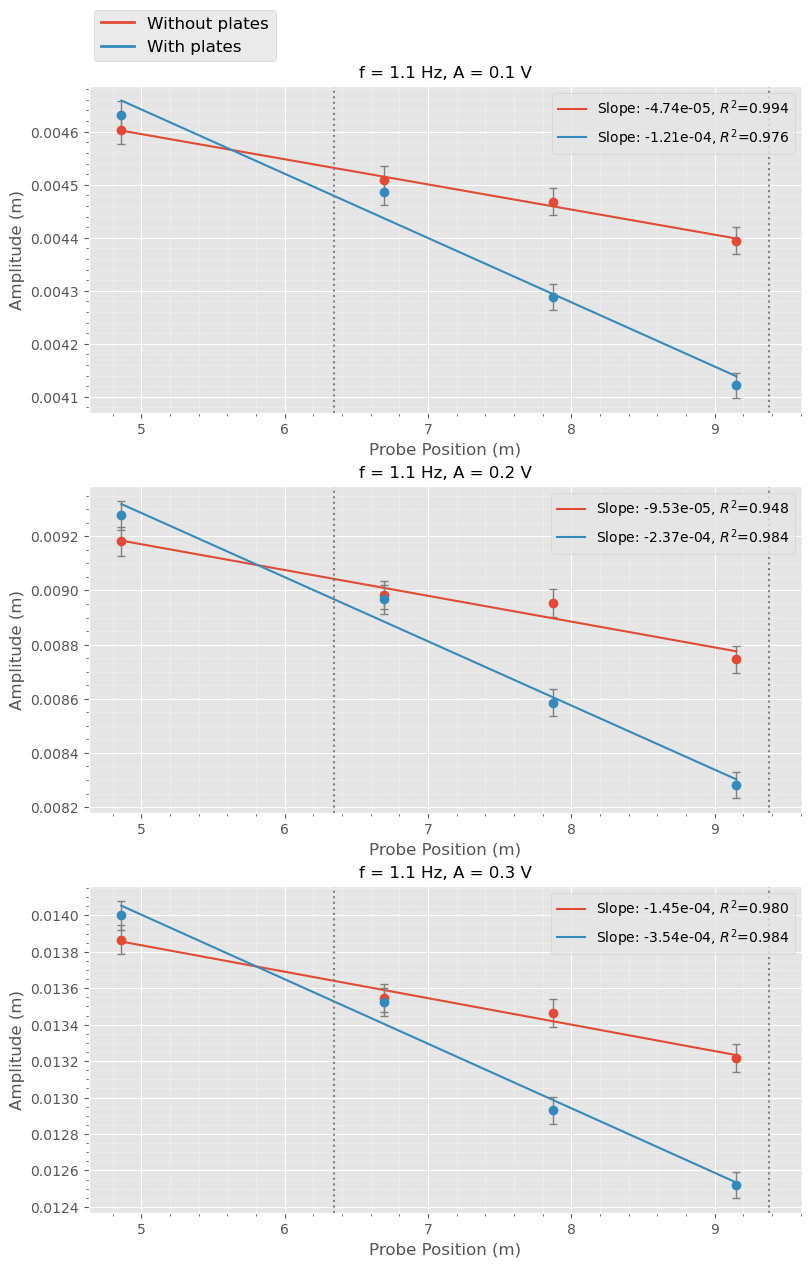

In [8]:
# Plotting
fig, ax = plt.subplots(3, 1, figsize=(8, 12), constrained_layout=True)

# A = 0.1 V
ax[0].errorbar(x_probe_pos,
            amp_f1_a1,
            yerr=std_err_f1_a1,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[0].plot(xx, line_f1_a1(xx), color= 'C0',
         label=rf'Slope: {coeff_f1_a1[0]:.2e}, $R^2$={r2_f1_a1:.3f}')

ax[0].errorbar(x_probe_pos,
            amp_f1_a1_p005,
            yerr=std_err_f1_a1_p005,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[0].plot(xx, line_f1_a1_p005(xx), color= 'C1',
         label=rf'Slope: {coeff_f1_a1_p005[0]:.2e}, $R^2$={r2_f1_a1_p005:.3f}')

# A = 0.2 V
ax[1].errorbar(x_probe_pos,
            amp_f1_a2,
            yerr=std_err_f1_a2,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[1].plot(xx, line_f1_a2(xx), color= 'C0',
         label=rf'Slope: {coeff_f1_a2[0]:.2e}, $R^2$={r2_f1_a2:.3f}')

ax[1].errorbar(x_probe_pos,
               amp_f1_a2_p005,
               yerr=std_err_f1_a2_p005,
               fmt='o',
               ecolor='grey',
               elinewidth=1,
               capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[1].plot(xx, line_f1_a2_p005(xx), color= 'C1',
         label=rf'Slope: {coeff_f1_a2_p005[0]:.2e}, $R^2$={r2_f1_a2_p005:.3f}')

# A = 0.3 V
ax[2].errorbar(x_probe_pos,
            amp_f1_a3,
            yerr=std_err_f1_a3,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[2].plot(xx, line_f1_a3(xx), color= 'C0',
         label=rf'Slope: {coeff_f1_a3[0]:.2e}, $R^2$={r2_f1_a3:.3f}')

ax[2].errorbar(x_probe_pos,
               amp_f1_a3_p005,
               yerr=std_err_f1_a3_p005,
               fmt='o',
               ecolor='grey',
               elinewidth=1,
               capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[2].plot(xx, line_f1_a3_p005(xx), color= 'C1',
         label=rf'Slope: {coeff_f1_a3_p005[0]:.2e}, $R^2$={r2_f1_a3_p005:.3f}')


for axs in ax:
    axs.axvline(x=plate_pos[0], color='0.5', linestyle=':')
    axs.axvline(x=plate_pos[1], color='0.5', linestyle=':')
    axs.grid(which='minor', linestyle=':', linewidth='0.5', color='white')
    axs.minorticks_on()
    axs.set_xlabel('Probe Position (m)', fontsize=12)
    axs.set_ylabel('Amplitude (m)', fontsize=12)
    axs.legend(fontsize=10, loc='upper right')

ax[0].set_title(f'f = 1.1 Hz, A = 0.1 V', fontsize=12)
ax[1].set_title(f'f = 1.1 Hz, A = 0.2 V', fontsize=12)
ax[2].set_title(f'f = 1.1 Hz, A = 0.3 V', fontsize=12)

handles = [Line2D([0], [0], linestyle=None, color='C0', lw=2, label='Without plates'),
           Line2D([0], [0], linestyle=None, color='C1', lw=2, label='With plates')]

fig.legend(handles=handles, loc='upper left', fontsize=12, bbox_to_anchor=(0.1, 1.05))

We have from above that, $a_{2} = a_{1}\frac{0.3}{0.2} = a_{1}*1.5$.

Which yields, $a_{2} = 1.5 * a_{1} = 1.5 * (k_{1}*V + b_{1})$. Thus, the voltage setting for the scaled amplitude at 30 cm water depth is, 

$V^* = \frac{a_{2} - 1.5*b_{1}}{1.5 * k_{1}}$.

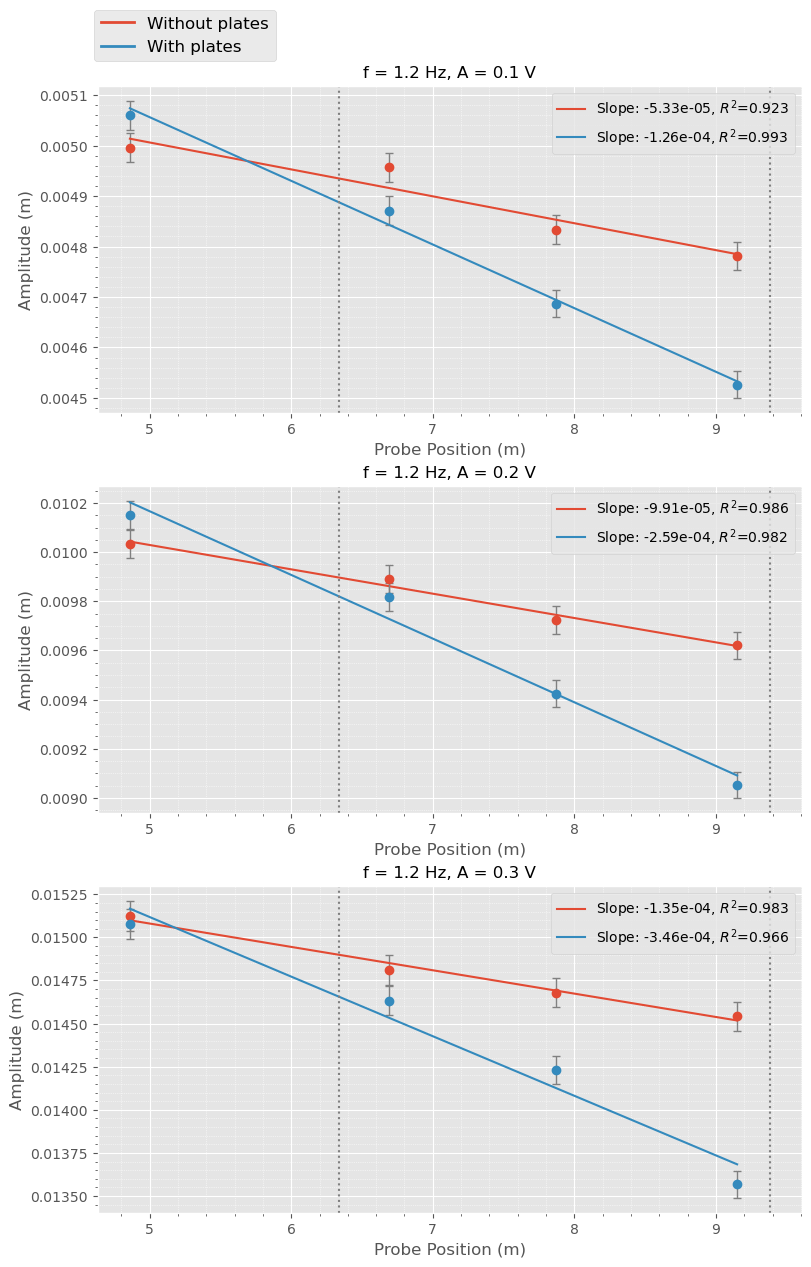

In [9]:
# Plotting
fig, ax = plt.subplots(3, 1, figsize=(8, 12), constrained_layout=True)

# A = 0.1 V
ax[0].errorbar(x_probe_pos,
            amp_f2_a1,
            yerr=std_err_f2_a1,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[0].plot(xx, line_f2_a1(xx), color= 'C0',
         label=rf'Slope: {coeff_f2_a1[0]:.2e}, $R^2$={r2_f2_a1:.3f}')

ax[0].errorbar(x_probe_pos,
            amp_f2_a1_p005,
            yerr=std_err_f2_a1_p005,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[0].plot(xx, line_f2_a1_p005(xx), color= 'C1',
         label=rf'Slope: {coeff_f2_a1_p005[0]:.2e}, $R^2$={r2_f2_a1_p005:.3f}')

# A = 0.2 V
ax[1].errorbar(x_probe_pos,
            amp_f2_a2,
            yerr=std_err_f2_a2,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[1].plot(xx, line_f2_a2(xx), color= 'C0',
         label=rf'Slope: {coeff_f2_a2[0]:.2e}, $R^2$={r2_f2_a2:.3f}')

ax[1].errorbar(x_probe_pos,
               amp_f2_a2_p005,
               yerr=std_err_f2_a2_p005,
               fmt='o',
               ecolor='grey',
               elinewidth=1,
               capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[1].plot(xx, line_f2_a2_p005(xx), color= 'C1',
         label=rf'Slope: {coeff_f2_a2_p005[0]:.2e}, $R^2$={r2_f2_a2_p005:.3f}')

# A = 0.3 V
ax[2].errorbar(x_probe_pos,
            amp_f2_a3,
            yerr=std_err_f2_a3,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[2].plot(xx, line_f2_a3(xx), color= 'C0',
         label=rf'Slope: {coeff_f2_a3[0]:.2e}, $R^2$={r2_f2_a3:.3f}')

ax[2].errorbar(x_probe_pos,
               amp_f2_a3_p005,
               yerr=std_err_f2_a3_p005,
               fmt='o',
               ecolor='grey',
               elinewidth=1,
               capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[2].plot(xx, line_f2_a3_p005(xx), color= 'C1',
         label=rf'Slope: {coeff_f2_a3_p005[0]:.2e}, $R^2$={r2_f2_a3_p005:.3f}')


for axs in ax:
    axs.axvline(x=plate_pos[0], color='0.5', linestyle=':')
    axs.axvline(x=plate_pos[1], color='0.5', linestyle=':')
    axs.grid(which='minor', linestyle=':', linewidth='0.5', color='white')
    axs.minorticks_on()
    axs.set_xlabel('Probe Position (m)', fontsize=12)
    axs.set_ylabel('Amplitude (m)', fontsize=12)
    axs.legend(fontsize=10, loc='upper right')

ax[0].set_title(f'f = 1.2 Hz, A = 0.1 V', fontsize=12)
ax[1].set_title(f'f = 1.2 Hz, A = 0.2 V', fontsize=12)
ax[2].set_title(f'f = 1.2 Hz, A = 0.3 V', fontsize=12)

handles = [Line2D([0], [0], linestyle=None, color='C0', lw=2, label='Without plates'),
           Line2D([0], [0], linestyle=None, color='C1', lw=2, label='With plates')]

fig.legend(handles=handles, loc='upper left', fontsize=12, bbox_to_anchor=(0.1, 1.05))

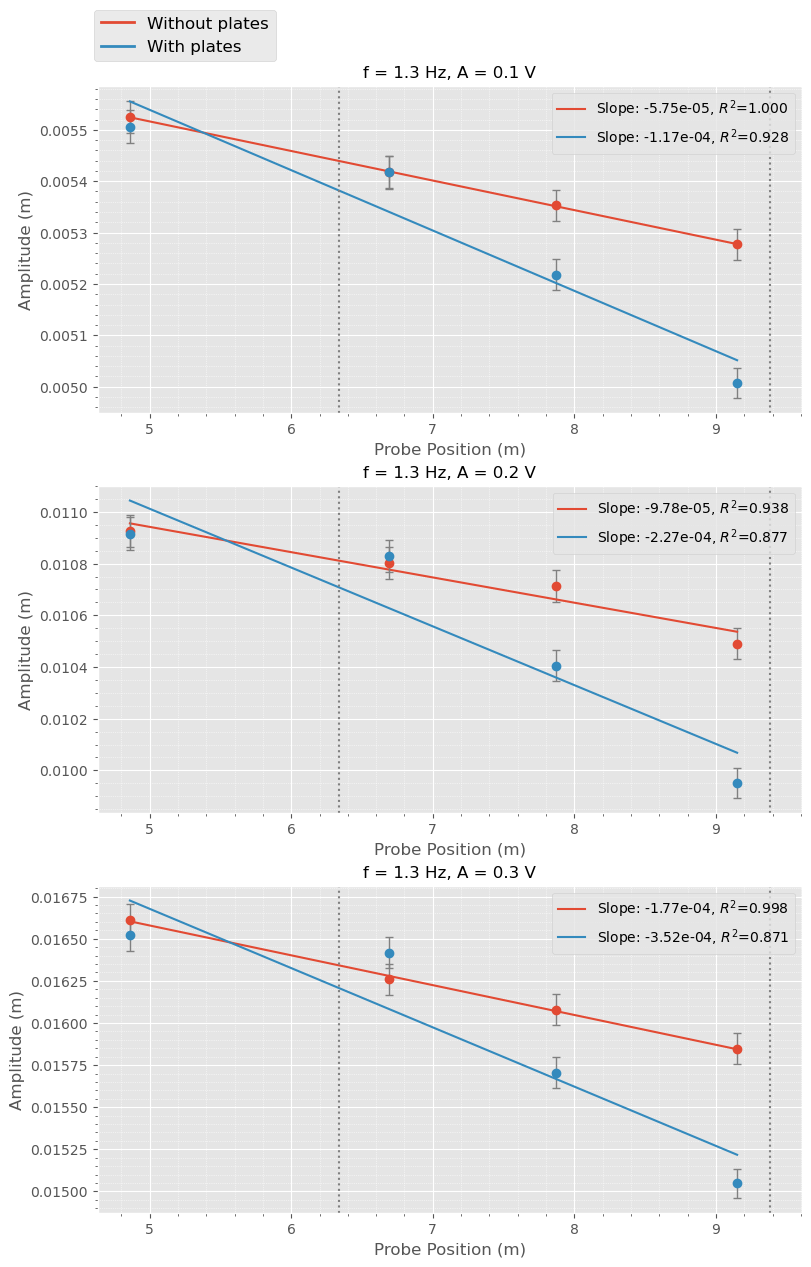

In [16]:
# Plotting
fig, ax = plt.subplots(3, 1, figsize=(8, 12), constrained_layout=True)

# A = 0.1 V
ax[0].errorbar(x_probe_pos,
            amp_f3_a1,
            yerr=std_err_f3_a1,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[0].plot(xx, line_f3_a1(xx), color= 'C0',
         label=rf'Slope: {coeff_f3_a1[0]:.2e}, $R^2$={r2_f3_a1:.3f}')

ax[0].errorbar(x_probe_pos,
            amp_f3_a1_p005,
            yerr=std_err_f3_a1_p005,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[0].plot(xx, line_f3_a1_p005(xx), color= 'C1',
         label=rf'Slope: {coeff_f3_a1_p005[0]:.2e}, $R^2$={r2_f3_a1_p005:.3f}')

# A = 0.2 V
ax[1].errorbar(x_probe_pos,
            amp_f3_a2,
            yerr=std_err_f3_a2,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[1].plot(xx, line_f3_a2(xx), color= 'C0',
         label=rf'Slope: {coeff_f3_a2[0]:.2e}, $R^2$={r2_f3_a2:.3f}')

ax[1].errorbar(x_probe_pos,
               amp_f3_a2_p005,
               yerr=std_err_f3_a2_p005,
               fmt='o',
               ecolor='grey',
               elinewidth=1,
               capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[1].plot(xx, line_f3_a2_p005(xx), color= 'C1',
         label=rf'Slope: {coeff_f3_a2_p005[0]:.2e}, $R^2$={r2_f3_a2_p005:.3f}')

# A = 0.3 V
ax[2].errorbar(x_probe_pos,
            amp_f3_a3,
            yerr=std_err_f3_a3,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[2].plot(xx, line_f3_a3(xx), color= 'C0',
         label=rf'Slope: {coeff_f3_a3[0]:.2e}, $R^2$={r2_f3_a3:.3f}')

ax[2].errorbar(x_probe_pos,
               amp_f3_a3_p005,
               yerr=std_err_f3_a3_p005,
               fmt='o',
               ecolor='grey',
               elinewidth=1,
               capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[2].plot(xx, line_f3_a3_p005(xx), color= 'C1',
         label=rf'Slope: {coeff_f3_a3_p005[0]:.2e}, $R^2$={r2_f3_a3_p005:.3f}')


for axs in ax:
    axs.axvline(x=plate_pos[0], color='0.5', linestyle=':')
    axs.axvline(x=plate_pos[1], color='0.5', linestyle=':')
    axs.grid(which='minor', linestyle=':', linewidth='0.5', color='white')
    axs.minorticks_on()
    axs.set_xlabel('Probe Position (m)', fontsize=12)
    axs.set_ylabel('Amplitude (m)', fontsize=12)
    axs.legend(fontsize=10, loc='upper right')

ax[0].set_title(f'f = 1.3 Hz, A = 0.1 V', fontsize=12)
ax[1].set_title(f'f = 1.3 Hz, A = 0.2 V', fontsize=12)
ax[2].set_title(f'f = 1.3 Hz, A = 0.3 V', fontsize=12)

handles = [Line2D([0], [0], linestyle=None, color='C0', lw=2, label='Without plates'),
           Line2D([0], [0], linestyle=None, color='C1', lw=2, label='With plates')]

fig.legend(handles=handles, loc='upper left', fontsize=12, bbox_to_anchor=(0.1, 1.05))

In [10]:
def obs_damping_coefficient(amp0, amp3, x0, x3):
    """
    Calculate observed spatial damping coefficients.

    (A_0 - A_3) / (x_3 - x_0)
    """

    return (amp0 - amp3) / (x3 - x0)

In [11]:
k_f1 = estimate_wavenumber(freq=1.1, depth=0.2)

alpha_theo_f1 = spatial_damping_coefficient(k=k_f1, D=0.2, H=0.15)

alpha_obs_f1_a1 = obs_damping_coefficient(amp0=amp_f1_a1[0], amp3=amp_f1_a1[3],
                                          x0=x_probe_pos[0], x3=x_probe_pos[3])
alpha_obs_f1_a1_p005 = obs_damping_coefficient(amp0=amp_f1_a1_p005[0], amp3=amp_f1_a1_p005[3],
                                                x0=x_probe_pos[0], x3=x_probe_pos[3])

alpha_obs_f1_a2 = obs_damping_coefficient(amp0=amp_f1_a2[0], amp3=amp_f1_a2[3],
                                          x0=x_probe_pos[0], x3=x_probe_pos[3])
alpha_obs_f1_a2_p005 = obs_damping_coefficient(amp0=amp_f1_a2_p005[0], amp3=amp_f1_a2_p005[3],
                                                x0=x_probe_pos[0], x3=x_probe_pos[3])
alpha_obs_f1_a3 = obs_damping_coefficient(amp0=amp_f1_a3[0], amp3=amp_f1_a3[3],
                                          x0=x_probe_pos[0], x3=x_probe_pos[3])
alpha_obs_f1_a3_p005 = obs_damping_coefficient(amp0=amp_f1_a3_p005[0], amp3=amp_f1_a3_p005[3],
                                                x0=x_probe_pos[0], x3=x_probe_pos[3])

print('Theoretical spatial damping coefficient (f=1.1 Hz): ', f'{alpha_theo_f1:.4f}')
print('Observed spatial damping coefficients (f=1.1 Hz):')
print(f' A=0.1 V, no plates: {alpha_obs_f1_a1:.4f}, with plates: {alpha_obs_f1_a1_p005:.4f}')
print(f' A=0.2 V, no plates: {alpha_obs_f1_a2:.4f}, with plates: {alpha_obs_f1_a2_p005:.4f}')
print(f' A=0.3 V, no plates: {alpha_obs_f1_a3:.4f}, with plates: {alpha_obs_f1_a3_p005:.4f}')

Theoretical spatial damping coefficient (f=1.1 Hz):  0.0148
Observed spatial damping coefficients (f=1.1 Hz):
 A=0.1 V, no plates: 0.0000, with plates: 0.0001
 A=0.2 V, no plates: 0.0001, with plates: 0.0002
 A=0.3 V, no plates: 0.0002, with plates: 0.0003


In [12]:
k_f2 = estimate_wavenumber(freq=1.2, depth=0.2)

alpha_theo_f2 = spatial_damping_coefficient(k=k_f2, D=0.2, H=0.15)

alpha_obs_f2_a1 = obs_damping_coefficient(amp0=amp_f2_a1[0], amp3=amp_f2_a1[3],
                                          x0=x_probe_pos[0], x3=x_probe_pos[3])
alpha_obs_f2_a1_p005 = obs_damping_coefficient(amp0=amp_f2_a1_p005[0], amp3=amp_f2_a1_p005[3],
                                                x0=x_probe_pos[0], x3=x_probe_pos[3])

alpha_obs_f2_a2 = obs_damping_coefficient(amp0=amp_f2_a2[0], amp3=amp_f2_a2[3],
                                          x0=x_probe_pos[0], x3=x_probe_pos[3])
alpha_obs_f2_a2_p005 = obs_damping_coefficient(amp0=amp_f2_a2_p005[0], amp3=amp_f2_a2_p005[3],
                                                x0=x_probe_pos[0], x3=x_probe_pos[3])
alpha_obs_f2_a3 = obs_damping_coefficient(amp0=amp_f2_a3[0], amp3=amp_f2_a3[3],
                                          x0=x_probe_pos[0], x3=x_probe_pos[3])
alpha_obs_f2_a3_p005 = obs_damping_coefficient(amp0=amp_f2_a3_p005[0], amp3=amp_f2_a3_p005[3],
                                                x0=x_probe_pos[0], x3=x_probe_pos[3])

print('Theoretical spatial damping coefficient (f=1.2 Hz): ', f'{alpha_theo_f2:.4f}')
print('Observed spatial damping coefficients (f=1.2 Hz):')
print(f' A=0.1 V, no plates: {alpha_obs_f2_a1:.4f}, with plates: {alpha_obs_f2_a1_p005:.4f}')
print(f' A=0.2 V, no plates: {alpha_obs_f2_a2:.4f}, with plates: {alpha_obs_f2_a2_p005:.4f}')
print(f' A=0.3 V, no plates: {alpha_obs_f2_a3:.4f}, with plates: {alpha_obs_f2_a3_p005:.4f}')

Theoretical spatial damping coefficient (f=1.2 Hz):  0.0148
Observed spatial damping coefficients (f=1.2 Hz):
 A=0.1 V, no plates: 0.0001, with plates: 0.0001
 A=0.2 V, no plates: 0.0001, with plates: 0.0003
 A=0.3 V, no plates: 0.0001, with plates: 0.0004


In [17]:
k_f3 = estimate_wavenumber(freq=1.2, depth=0.2)

alpha_theo_f3 = spatial_damping_coefficient(k=k_f3, D=0.2, H=0.15)

alpha_obs_f3_a1 = obs_damping_coefficient(amp0=amp_f3_a1[0], amp3=amp_f3_a1[3],
                                          x0=x_probe_pos[0], x3=x_probe_pos[3])
alpha_obs_f3_a1_p005 = obs_damping_coefficient(amp0=amp_f3_a1_p005[0], amp3=amp_f3_a1_p005[3],
                                                x0=x_probe_pos[0], x3=x_probe_pos[3])

alpha_obs_f3_a2 = obs_damping_coefficient(amp0=amp_f3_a2[0], amp3=amp_f3_a2[3],
                                          x0=x_probe_pos[0], x3=x_probe_pos[3])
alpha_obs_f3_a2_p005 = obs_damping_coefficient(amp0=amp_f3_a2_p005[0], amp3=amp_f3_a2_p005[3],
                                                x0=x_probe_pos[0], x3=x_probe_pos[3])
alpha_obs_f3_a3 = obs_damping_coefficient(amp0=amp_f3_a3[0], amp3=amp_f3_a3[3],
                                          x0=x_probe_pos[0], x3=x_probe_pos[3])
alpha_obs_f3_a3_p005 = obs_damping_coefficient(amp0=amp_f3_a3_p005[0], amp3=amp_f3_a3_p005[3],
                                                x0=x_probe_pos[0], x3=x_probe_pos[3])

print('Theoretical spatial damping coefficient (f=1.2 Hz): ', f'{alpha_theo_f3:.4f}')
print('Observed spatial damping coefficients (f=1.2 Hz):')
print(f' A=0.1 V, no plates: {alpha_obs_f3_a1:.4f}, with plates: {alpha_obs_f3_a1_p005:.4f}')
print(f' A=0.2 V, no plates: {alpha_obs_f3_a2:.4f}, with plates: {alpha_obs_f3_a2_p005:.4f}')
print(f' A=0.3 V, no plates: {alpha_obs_f3_a3:.4f}, with plates: {alpha_obs_f3_a3_p005:.4f}')

Theoretical spatial damping coefficient (f=1.2 Hz):  0.0148
Observed spatial damping coefficients (f=1.2 Hz):
 A=0.1 V, no plates: 0.0001, with plates: 0.0001
 A=0.2 V, no plates: 0.0001, with plates: 0.0002
 A=0.3 V, no plates: 0.0002, with plates: 0.0003
